# IMPORT LIBRARIES

In [29]:
import torch
from torch import nn
from torchvision import datasets , transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import os

# --------------------------------------------------------------------------

# IMPORTANT UNDERSTANDING

# Unlike CIFAR10:

# Intel dataset is stored as folders.

#----------------------------------------------------------------------------

# DOWNLOAD DATASET

In [30]:
import kagglehub
path=kagglehub.dataset_download(
  "puneet6060/intel-image-classification"
)
print(path)

C:\Users\ahlaw\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2


# UNDERSTAND DATASET STRUCTURE

In [31]:
os.listdir(path)

# VERY Important

# This dataset is NOT:

# CSV
# tensors
# arrays.

# It is actual image folders.

['seg_pred', 'seg_test', 'seg_train']

# CREATE TRAIN/TEST PATHS

In [32]:
train_path=os.path.join(
  path,
  "seg_train",
  "seg_train"
)

test_path=os.path.join(
  path,
  "seg_test",
  "seg_test"
)

print(train_path)
print(test_path)

C:\Users\ahlaw\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
C:\Users\ahlaw\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_test\seg_test


# INSPECT CLASSES

In [33]:
os.listdir(train_path)

# VERY Important Observation

# These folder names automatically become:

# class labels

# inside PyTorch.

# This is how:

# ImageFolder
# custom datasets

# work.

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

# CREATE TRANSFORMS

In [34]:
transform=transforms.Compose([
  transforms.Resize((128,128)),
  transforms.ToTensor()
])

# LOAD DATASET USING ImageFolder

In [35]:
train_data=datasets.ImageFolder(
  root=train_path,
  transform=transform
)

test_data=datasets.ImageFolder(
  root=test_path,
  transform=transform
)

In [36]:
train_data

Dataset ImageFolder
    Number of datapoints: 14034
    Root location: C:\Users\ahlaw\.cache\kagglehub\datasets\puneet6060\intel-image-classification\versions\2\seg_train\seg_train
    StandardTransform
Transform: Compose(
               Resize(size=(128, 128), interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
           )

# INSPECT CLASS MAPPING

In [37]:
train_data.class_to_idx

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [38]:
test_data.class_to_idx

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

# INSPECT DATASET SIZE

In [39]:
print(len(train_data))
print(len(test_data))

14034
3000


# CHECK ONE SAMPLE

In [40]:
image,label=train_data[0]
print(image.shape)
print(label)

torch.Size([3, 128, 128])
0


# VISUALIZE IMAGE

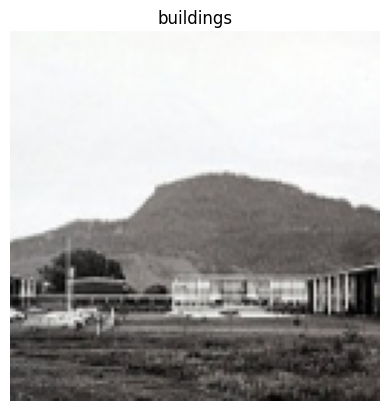

In [41]:
plt.imshow(image.permute(1,2,0))
plt.title(
  train_data.classes[label]
)
plt.axis(False)
plt.show()

# CREATE DATALOADERS

In [42]:
train_dataloader=DataLoader(
  train_data,
  batch_size=32,
  shuffle=True,
  num_workers=2,
  pin_memory=True
)

test_dataloader=DataLoader(
  test_data,
  batch_size=32,
  shuffle=False,
  num_workers=2,
  pin_memory=True
)

# INSPECT ONE BATCH

In [43]:
images,labels=next(iter(train_dataloader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 128, 128])
torch.Size([32])


# VISUALIZE BATCH IMAGES

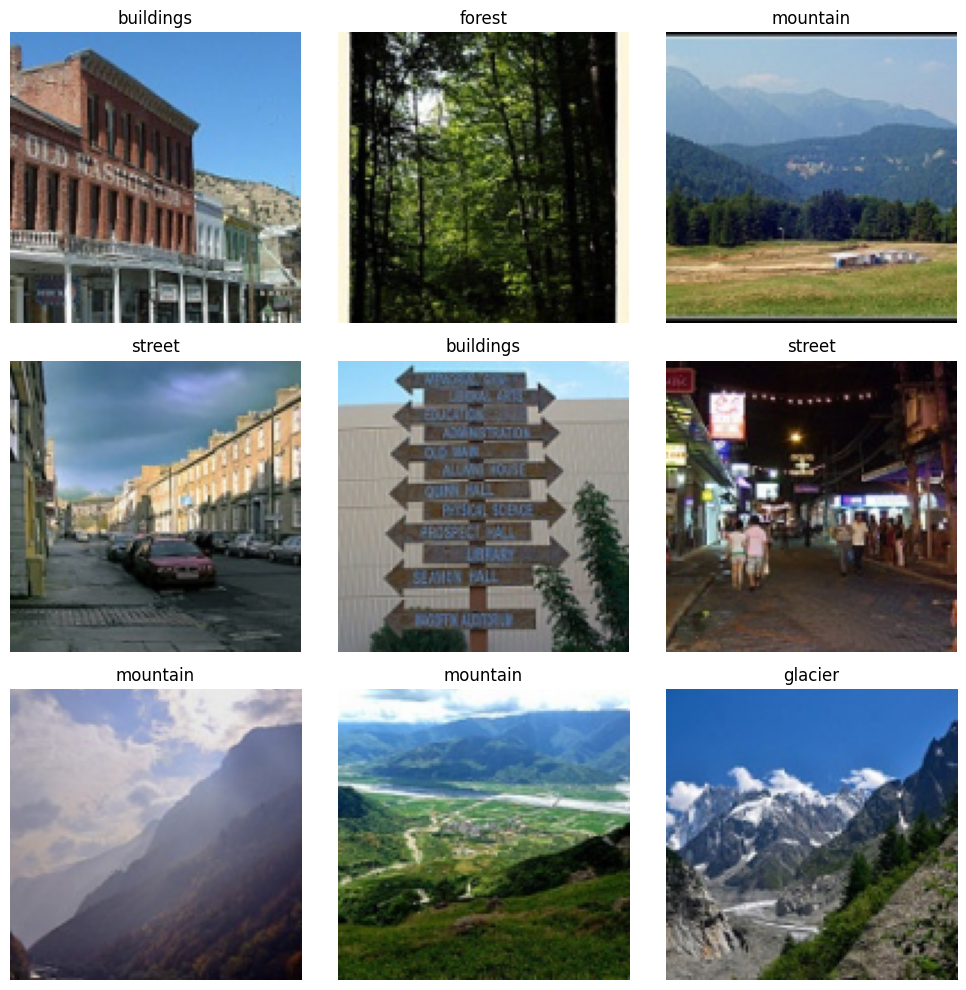

In [44]:
fig=plt.figure(figsize=(10,10))

for i in range(9) : 
  ax=fig.add_subplot(3,3,i+1)
  img=images[i]
  label=labels[i]
  ax.imshow(img.permute(1,2,0))
  
  ax.set_title(
    train_data.classes[label]
  )
  ax.axis(False)
  
plt.tight_layout()
plt.show()

# Now we'll begin with baseline_cnn and this will become our model_0

#### DEVICE SETUP

In [45]:
device="cuda" if torch.cuda.is_available() else "cpu"
print(device)

cuda


## BUILD BASELINE CNN (model_0)

In [46]:
class TinyVGG(nn.Module):
  def __init__(self):
    super().__init__()
    self.conv_block_1=nn.Sequential(
      nn.Conv2d(
        in_channels=3,
        out_channels=32,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.Conv2d(
        in_channels=32,
        out_channels=32,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )
    
    self.conv_block_2=nn.Sequential(
      nn.Conv2d(
        in_channels=32,
        out_channels=64,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.Conv2d(
        in_channels=64,
        out_channels=64,
        kernel_size=3,
        padding=1
      ),
      nn.ReLU(),
      nn.MaxPool2d(kernel_size=2)
    )
    
    self.classifier=nn.Sequential(
      nn.Flatten(),
      nn.Linear(
        in_features=64*32*32,
        out_features=len(train_data.classes)
      )
    )
    
  
  def forward(self,x):
    x=self.conv_block_1(x)
    x=self.conv_block_2(x)
    x=self.classifier(x)
    
    return x
      

# CREATE model_0

In [47]:
model_0=TinyVGG().to(device)

# Verify Output Shape

In [48]:
X,y=next(iter(train_dataloader))
X=X.to(device)
y=y.to(device)
output=model_0(X)
print(output)
print(output.shape)

tensor([[ 1.6844e-02, -1.2559e-02,  2.2914e-02, -1.0461e-02, -6.8976e-03,
          1.9844e-02],
        [ 1.6742e-02, -7.4856e-03,  2.1078e-02, -5.2413e-03, -3.2539e-03,
          1.3904e-02],
        [ 1.8366e-02, -8.5157e-03,  2.1634e-02, -1.2451e-02, -5.3247e-03,
          1.7809e-02],
        [ 1.9063e-02, -5.4881e-03,  1.4003e-02,  4.8495e-05, -1.3400e-02,
          1.1473e-02],
        [ 2.6252e-02,  1.4431e-03,  1.4368e-02, -3.5526e-03, -5.2252e-03,
          8.6025e-03],
        [ 1.7227e-02, -1.1346e-02,  2.0675e-02, -4.1890e-03, -9.5754e-03,
          1.4704e-02],
        [ 1.6762e-02, -1.3439e-02,  2.1664e-02, -6.8730e-03, -6.8539e-03,
          1.6426e-02],
        [ 1.9078e-02, -9.0143e-03,  1.8705e-02, -7.7190e-03,  3.2274e-03,
          1.9424e-02],
        [ 2.0998e-02,  1.0762e-03,  1.2765e-02,  3.8580e-03, -8.3040e-03,
          9.4761e-03],
        [ 1.8539e-02, -5.3978e-03,  2.1384e-02, -6.6307e-03, -7.8629e-03,
          1.7710e-02],
        [ 2.0710e-02, -5.6549e

# CREATE TRAIN FUNCTION

In [ ]:
def train_step(
  model,
  dataloader,
  loss_fn,
  optimizer,
  device
) : 
  model.train()
  
  train_loss=0
  correct=0
  for X,y in dataloader : 
    X,y=X.to(device) , y.to(device)
    # forward pass
    y_logits=model(X)
    # loss
    loss=loss_fn(y_logits,y)
    train_loss+=loss.item()
    
    # predictions
    y_pred=torch.argmax(y_logits,dim=1)
    correct+=(y_pred==y).sum().item()
    
    # optimizer step
    optimizer.zero_grad()
    
    loss.backward()
    optimizer.step()
  train_loss/=len(dataloader)
  train_acc=correct/len(dataloader.dataset)
  
  return train_loss , train_acc
    
    
    
    # Returns:

# train_loss
# train_acc

# for ONE epoch.
    

# CREATE TEST FUNCTION

In [52]:
def test_step(
  model,
  dataloader,
  loss_fn,
  device
) : 
  model.eval()
  test_loss=0
  correct=0
  
  with torch.inference_mode() : 
    for X,y in dataloader : 
      X,y=X.to(device) , y.to(device)
      test_logits=model(X)
      loss=loss_fn(test_logits,y)
      test_loss+=loss.item()
      
      y_pred=torch.argmax(test_logits,dim=1)
      correct+=(y_pred==y).sum().item()
    
  test_loss/=len(dataloader)
  test_acc=correct/len(dataloader.dataset)
  
  return test_loss , test_acc

# CREATE EXPERIMENT RESULTS DICTIONARY

In [53]:
results={}

# SETUP model_0

In [54]:
loss_fn=nn.CrossEntropyLoss()

optimizer=torch.optim.Adam(
  model_0.parameters(),
  lr=0.001
)

# CREATE TRAINING TRACKERS

In [55]:
model_0_results={
  "train_loss":[],
  "train_acc":[],
  "test_loss":[],
  "test_acc":[]
}

# TRAIN model_0

In [56]:
epochs=5

for epoch in range(epochs):
  train_loss , train_acc= train_step(
    model=model_0,
    dataloader=train_dataloader,
    loss_fn=loss_fn,
    optimizer=optimizer,
    device=device
  )
  
  test_loss , test_acc=test_step(
    model=model_0,
    dataloader=test_dataloader,
    loss_fn=loss_fn,
    device=device
  )
  
  # store results
  model_0_results["train_loss"].append(train_loss)
  model_0_results["train_acc"].append(train_acc)
  model_0_results["test_loss"].append(test_loss)
  model_0_results["test_acc"].append(test_acc)
  
  print(f"Epoch: {epoch+1}")

  print(f"Train Loss: {train_loss:.4f}")

  print(f"Train Accuracy: {train_acc*100:.2f}%")

  print(f"Test Loss: {test_loss:.4f}")

  print(f"Test Accuracy: {test_acc*100:.2f}%\n")

Epoch: 1
Train Loss: 1.0045
Train Accuracy: 60.92%
Test Loss: 0.7964
Test Accuracy: 70.07%

Epoch: 2
Train Loss: 0.7007
Train Accuracy: 74.21%
Test Loss: 0.6847
Test Accuracy: 74.77%

Epoch: 3
Train Loss: 0.5753
Train Accuracy: 79.13%
Test Loss: 0.6028
Test Accuracy: 77.93%

Epoch: 4
Train Loss: 0.4380
Train Accuracy: 84.25%
Test Loss: 0.6853
Test Accuracy: 77.60%

Epoch: 5
Train Loss: 0.3060
Train Accuracy: 89.10%
Test Loss: 0.7160
Test Accuracy: 79.33%



# PLOT LOSS CURVES

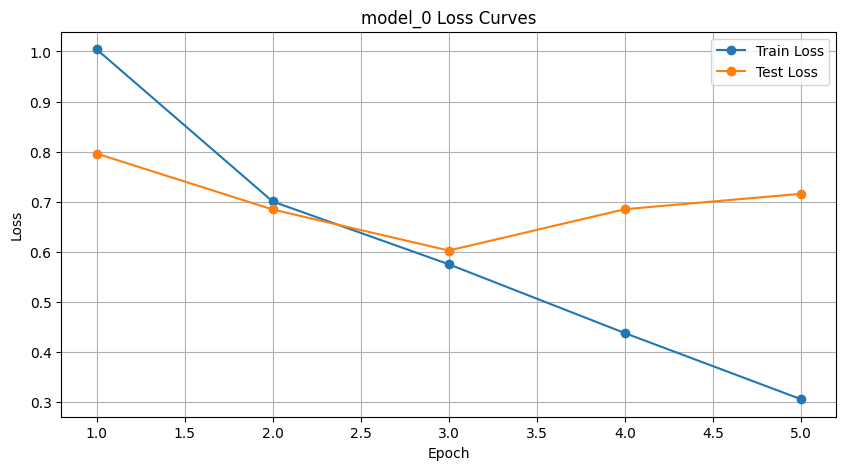

In [57]:
import matplotlib.pyplot as plt
epochs_range=range(1,epochs+1)

plt.figure(figsize=(10,5))

plt.plot(
  epochs_range,
  model_0_results["train_loss"],
  marker='o',
  label="Train Loss"
)

plt.plot(
    epochs_range,
    model_0_results["test_loss"],
    marker='o',
    label="Test Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("model_0 Loss Curves")

plt.legend()

plt.grid(True)

plt.show()


# PLOT ACCURACY CURVES

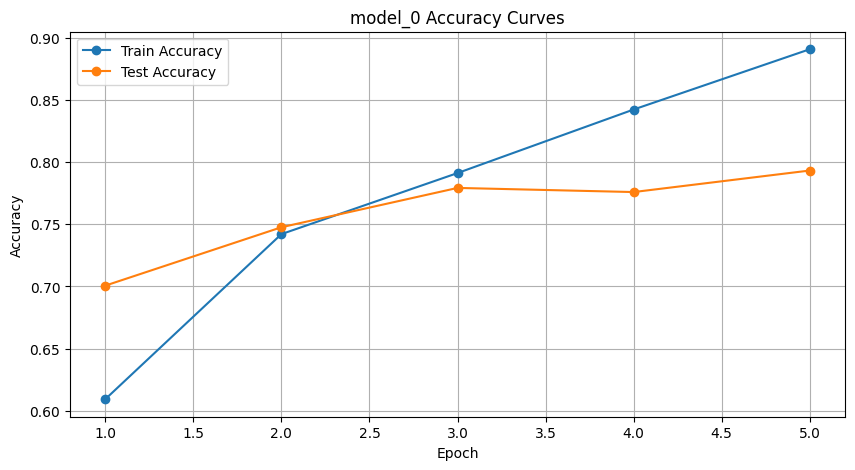

In [58]:
plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    model_0_results["train_acc"],
    marker='o',
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    model_0_results["test_acc"],
    marker='o',
    label="Test Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("model_0 Accuracy Curves")

plt.legend()

plt.grid(True)

plt.show()

# STORE RESULTS GLOBALLY

In [59]:
results["model_0"] = model_0_results

# CREATE QUICK SUMMARY TABLE

In [60]:
import pandas as pd

summary_df = pd.DataFrame({

    "Model": ["model_0"],

    "Final Train Accuracy": [
        model_0_results["train_acc"][-1] * 100
    ],

    "Final Test Accuracy": [
        model_0_results["test_acc"][-1] * 100
    ]

})

summary_df

,Model,Final Train Accuracy,Final Test Accuracy
0,model_0,89.097905,79.333333


In [62]:
print(len(train_data))
print(len(test_data))

14034
3000


# IMPORT RESNET18

In [63]:
from torchvision.models import (
  resnet18,
  ResNet18_Weights
)

# LOAD PRETRAINED MODEL

In [64]:
model_1=resnet18(
  weights=ResNet18_Weights.DEFAULT
)

## INSPECT FINAL LAYER

In [65]:
print(model_1)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [66]:
print(model_1.fc)

Linear(in_features=512, out_features=1000, bias=True)


# REPLACE FINAL CLASSIFIER

In [ ]:
model_1.fc=nn.Linear(
  in_features=512,
  out_features=len(train_data.classes)
)

# We are:

# keeping pretrained feature extractor
# replacing task-specific classifier.

# This is the CORE of transfer learning.

# FREEZE PRETRAINED LAYERS

In [ ]:
for param in model_1.parameters():
  param.requires_grad=False
  
  
  # WHAT DOES THIS DO?

# Prevents:

# pretrained weights from changing.

# Meaning:

# ResNet visual knowledge preserved.


# But this ALSO froze:

# final FC layer.

# So now we re-enable it.

# UNFREEZE CLASSIFIER

In [70]:
for param in model_1.fc.parameters():
  param.requires_grad=True

# MOVE TO GPU

In [71]:
model_1=model_1.to(device)

# CREATE LOSS + OPTIMIZER

In [72]:
loss_fn=nn.CrossEntropyLoss()
optimizer=torch.optim.Adam(
  model_1.fc.parameters(),
  lr=0.001
)

# CREATE RESULTS TRACKER

In [73]:
model_1_results = {

    "train_loss": [],

    "train_acc": [],

    "test_loss": [],

    "test_acc": []

}

# TRAIN model_1

In [74]:
epochs = 5

for epoch in range(epochs):

    train_loss, train_acc = train_step(

        model=model_1,

        dataloader=train_dataloader,

        loss_fn=loss_fn,

        optimizer=optimizer,

        device=device
    )

    test_loss, test_acc = test_step(

        model=model_1,

        dataloader=test_dataloader,

        loss_fn=loss_fn,

        device=device
    )

    # STORE RESULTS
    model_1_results["train_loss"].append(train_loss)

    model_1_results["train_acc"].append(train_acc)

    model_1_results["test_loss"].append(test_loss)

    model_1_results["test_acc"].append(test_acc)

    print(f"Epoch: {epoch+1}")

    print(f"Train Loss: {train_loss:.4f}")

    print(f"Train Accuracy: {train_acc*100:.2f}%")

    print(f"Test Loss: {test_loss:.4f}")

    print(f"Test Accuracy: {test_acc*100:.2f}%\n")

Epoch: 1
Train Loss: 0.5901
Train Accuracy: 79.78%
Test Loss: 0.3877
Test Accuracy: 86.90%

Epoch: 2
Train Loss: 0.3956
Train Accuracy: 86.16%
Test Loss: 0.3761
Test Accuracy: 87.07%

Epoch: 3
Train Loss: 0.3757
Train Accuracy: 86.70%
Test Loss: 0.3597
Test Accuracy: 87.30%

Epoch: 4
Train Loss: 0.3556
Train Accuracy: 87.00%
Test Loss: 0.3478
Test Accuracy: 87.73%

Epoch: 5
Train Loss: 0.3471
Train Accuracy: 87.51%
Test Loss: 0.3471
Test Accuracy: 87.77%



# STORE model_1 RESULTS

In [75]:
results["model_1"]=model_1_results

# PLOT model_1 LOSS CURVES

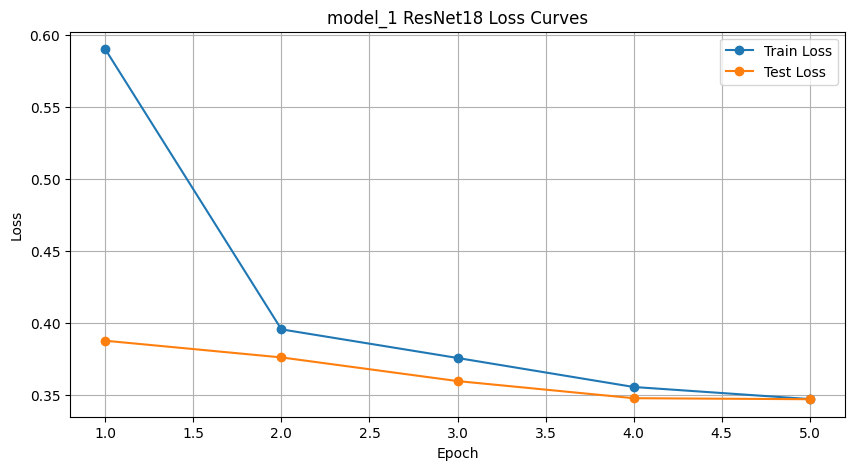

In [76]:
epochs_range = range(1, epochs+1)

plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    model_1_results["train_loss"],
    marker='o',
    label="Train Loss"
)

plt.plot(
    epochs_range,
    model_1_results["test_loss"],
    marker='o',
    label="Test Loss"
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.title("model_1 ResNet18 Loss Curves")

plt.legend()

plt.grid(True)

plt.show()

# PLOT model_1 ACCURACY CURVES

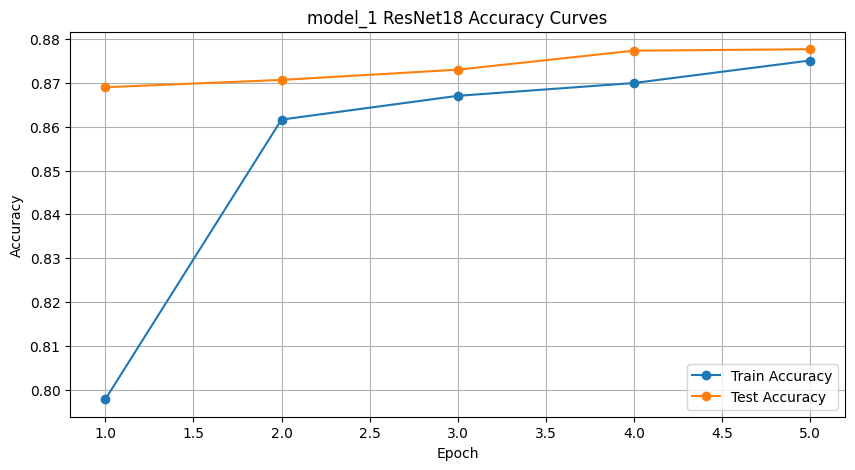

In [77]:
plt.figure(figsize=(10,5))

plt.plot(
    epochs_range,
    model_1_results["train_acc"],
    marker='o',
    label="Train Accuracy"
)

plt.plot(
    epochs_range,
    model_1_results["test_acc"],
    marker='o',
    label="Test Accuracy"
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.title("model_1 ResNet18 Accuracy Curves")

plt.legend()

plt.grid(True)

plt.show()

# CREATE COMPARISON TABLE


In [78]:
comparison_df = pd.DataFrame({

    "Model": [

        "model_0 CNN",

        "model_1 ResNet18"

    ],

    "Final Train Accuracy": [

        model_0_results["train_acc"][-1] * 100,

        model_1_results["train_acc"][-1] * 100
    ],

    "Final Test Accuracy": [

        model_0_results["test_acc"][-1] * 100,

        model_1_results["test_acc"][-1] * 100
    ]

})

comparison_df

,Model,Final Train Accuracy,Final Test Accuracy
0,model_0 CNN,89.097905,79.333333
1,model_1 ResNet18,87.508907,87.766667


# ACCURACY BAR PLOT

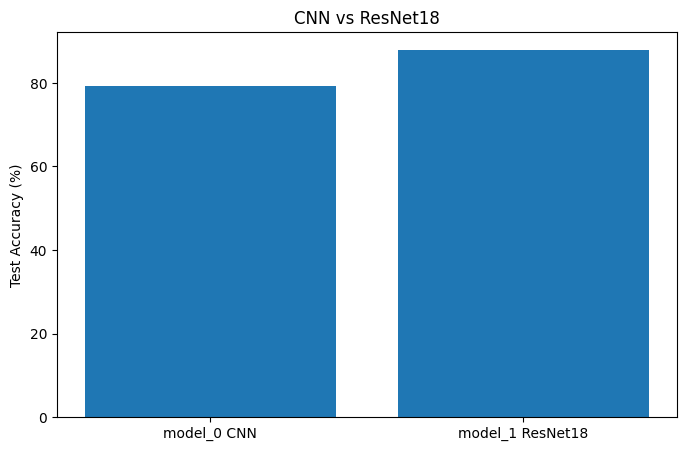

In [79]:
plt.figure(figsize=(8,5))

plt.bar(

    comparison_df["Model"],

    comparison_df["Final Test Accuracy"]

)

plt.ylabel("Test Accuracy (%)")

plt.title("CNN vs ResNet18")

plt.show()